Importamos las librerías necesarias

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt


utilizamos los siguientes parámetros:

In [48]:
learning_rate = 0.001
momentum = 0.9
epochs = 30
batch_size = 10
num_classes = 10

Carga de datos

In [49]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar y aplanar (28x28 -> 784)
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0

# One-hot encoding de las etiquetas
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

Implementación del modelo secuancial

In [50]:
model = Sequential()
model.add(Dense(30, activation='sigmoid', input_shape=(784,)))
#saldra en una capa de 10 neuronas usando la sigmoide
model.add(Dense(num_classes, activation='sigmoid'))

optimizer = SGD(learning_rate=learning_rate, momentum=momentum)
model.compile(loss="binary_crossentropy",optimizer=optimizer, metrics=["accuracy"])

history = model.fit(x_train,
                    y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=1)

Epoch 1/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 374us/step - accuracy: 0.4278 - loss: 0.3224 - val_accuracy: 0.6442 - val_loss: 0.2859
Epoch 2/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 355us/step - accuracy: 0.6799 - loss: 0.2649 - val_accuracy: 0.7205 - val_loss: 0.2431
Epoch 3/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 359us/step - accuracy: 0.7328 - loss: 0.2263 - val_accuracy: 0.7602 - val_loss: 0.2084
Epoch 4/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 375us/step - accuracy: 0.7685 - loss: 0.1965 - val_accuracy: 0.7918 - val_loss: 0.1825
Epoch 5/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 361us/step - accuracy: 0.7950 - loss: 0.1744 - val_accuracy: 0.8132 - val_loss: 0.1633
Epoch 6/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 361us/step - accuracy: 0.8150 - loss: 0.1578 - val_accuracy: 0.8278 - val_loss: 0.1487
Epoch 7/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 360us/step - accuracy: 0.8282 - loss: 0.1449 - val_accuracy: 0.8424 - val_loss: 0.1372
Epoch 8/30
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 2s 361us/step - accuracy: 0.8399 -

In [51]:
score = model.evaluate(x_test, y_test, verbose=1)
print(f"Test loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - accuracy: 0.9109 - loss: 0.0676
Test loss: 0.0676
Test accuracy: 0.9109


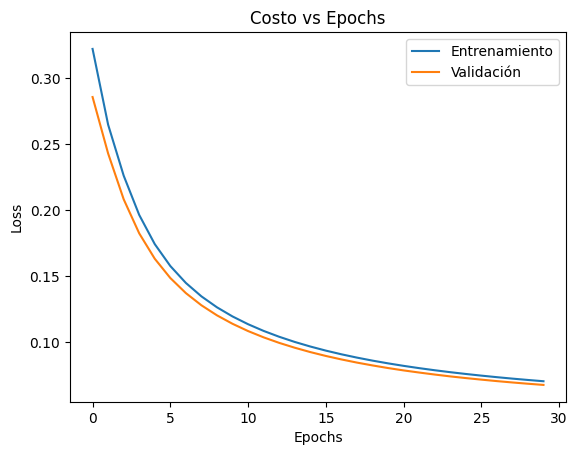

In [52]:
plt.plot(history.history['loss'], label="Entrenamiento")
plt.plot(history.history['val_loss'], label="Validación")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Costo vs Epochs")
plt.legend()
plt.show()